In [1]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      48
  On-line CPU(s) list:       0-47
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) Platinum 8268 CPU @ 2.90GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      1
    Core(s) per socket:      24
    Socket(s):               2
    Stepping:                7
    CPU(s) scaling MHz:      72%
    CPU max MHz:             3900.0000
    CPU min MHz:             1200.0000
    BogoMIPS:                5800.00
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush dts acpi mmx fxsr sse 
                             sse2 ss ht tm pbe syscall nx pdpe1gb rdtscp lm cons
                             tant_tsc art arch_perfmo

In [2]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [4]:
import arviz as az
import pymc as pm
from matplotlib import pyplot as plt
import hssm
import pandas as pd
from hssm.likelihoods import DDM
import pytensor 
import pytensor.tensor as pt
from pytensor.graph.op import Op 
import pickle as pkl 
import numpy as np
import time 
from scipy.optimize import fmin, minimize, LinearConstraint, Bounds 
from efficient_fpt.multi_stage_cy import (compute_loss_parallel, print_num_threads, compute_glamloss_parallel)
import jax 
import jax.numpy as jnp 
from jax import grad,jit,vmap 

print(f"PyMC version: {pm.__version__}")
print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")

/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


PyMC version: 5.27.1
JAX version: 0.9.0.1


ERROR:2026-02-20 14:56:37,532:jax._src.xla_bridge:491: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 489, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load 

JAX devices: [CpuDevice(id=0)]


In [4]:
# Simulate data 
NUM_TRIALS = 500     # Number of trials to simulate
RANDOM_SEED = 42       # For reproducibility

# True parameters for data generation
TRUE_PARAMS = {
    'eta': 0.7,        # Attention discount factor (0-1)
    'kappa': 0.5,      # Drift scaling
    'a': 2.1,          # Initial boundary
    'b': 0.0,          # Boundary collapse rate
    'x0': -0.2,        # Starting position
    'sigma': 1.0,      # Diffusion coefficient (fixed)
}

# Fixation time distribution parameters (Gamma)
FIXATION_SHAPE = 6
FIXATION_SCALE = 0.1

print(f"Simulating {NUM_TRIALS} trials with:")
for k, v in TRUE_PARAMS.items():
    print(f"  {k} = {v}")

# Import simulator
from efficient_fpt.models import DDModel, piecewise_const_func
from efficient_fpt.utils import get_alternating_mu_array

class aDDModel(DDModel):
    """Attentional Drift Diffusion Model for a single trial."""
    def __init__(self, mu1, mu2, sacc_array, flag, sigma, a, b, x0):
        super().__init__(x0)
        self.mu1 = mu1
        self.mu2 = mu2
        self.sacc_array = sacc_array
        self.flag = flag  # 0: start with mu1, 1: start with mu2
        self.d = len(sacc_array)
        self.mu_array = get_alternating_mu_array(mu1, mu2, self.d, flag)
        self.sigma = sigma
        self.a = a
        self.b = b

    def drift_coeff(self, X, t):
        return piecewise_const_func(t, self.mu_array, self.sacc_array)

    def diffusion_coeff(self, X, t):
        return self.sigma

    @property
    def is_update_vectorizable(self):
        return True

    def upper_bdy(self, t):
        return self.a - self.b * t

    def lower_bdy(self, t):
        return -self.a + self.b * t

def simulate_trial(rng, eta, kappa, sigma, a, b, x0, T_max, shape, scale):
    """Simulate a single aDDM trial."""
    # Generate fixation times
    fixations = rng.gamma(shape, scale, 100)
    sacc_array = np.insert(np.cumsum(fixations), 0, 0)
    sacc_array = sacc_array[sacc_array < T_max]
    
    # Random initial attention and stimulus values
    flag = rng.integers(0, 2)
    r1 = rng.integers(1, 6)
    r2 = rng.integers(1, 6)
    
    # Compute drift rates
    mu1 = kappa * (r1 - eta * r2)
    mu2 = kappa * (eta * r1 - r2)
    
    # Simulate
    model = aDDModel(mu1, mu2, sacc_array, flag, sigma, a, b, x0)
    rt, choice = model.simulate_fpt_datum(dt=1e-4)
    
    # Truncate saccade array to actual RT
    sacc_array = sacc_array[sacc_array < rt]
    d = len(sacc_array)
    mu_array = get_alternating_mu_array(mu1, mu2, d, flag)
    
    return {
        'rt': rt,
        'choice': int(choice),
        'mu_array': mu_array,
        'sacc_array': sacc_array,
        'd': d,
        'r1': r1,
        'r2': r2,
        'flag': flag,
        'mu1': mu1,
        'mu2': mu2,
    }

# Simulate data
print(f"Simulating {NUM_TRIALS} trials...")
rng = np.random.default_rng(RANDOM_SEED)
T_max = TRUE_PARAMS['a'] 

start = time.time()
trials = []
for i in range(NUM_TRIALS):
    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{NUM_TRIALS}...")
    trial = simulate_trial(
        rng, TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'], 
        TRUE_PARAMS['sigma'], TRUE_PARAMS['a'], TRUE_PARAMS['b'], 
        TRUE_PARAMS['x0'], T_max, FIXATION_SHAPE, FIXATION_SCALE
    )
    trials.append(trial)

print(f"Simulation completed in {time.time() - start:.1f}s")



Simulating 500 trials with:
  eta = 0.7
  kappa = 0.5
  a = 2.1
  b = 0.0
  x0 = -0.2
  sigma = 1.0
Simulating 500 trials...
  200/500...
  400/500...
Simulation completed in 269.2s


In [ ]:
# Prepare data arrays
rt_data = np.array([t['rt'] for t in trials], dtype=np.float64)
choice_data = np.array([t['choice'] for t in trials], dtype=np.int32)
d_data = np.array([t['d'] for t in trials], dtype=np.int32)
r1_data = np.array([t['r1'] for t in trials], dtype=np.float64)
r2_data = np.array([t['r2'] for t in trials], dtype=np.float64)
flag_data = np.array([t['flag'] for t in trials], dtype=np.int32)
mu1_data = np.array([t['mu1'] for t in trials], dtype=np.float64)
mu2_data = np.array([t['mu2'] for t in trials], dtype=np.float64)

# Pad arrays to max length
max_d = max(d_data)
mu_data_padded = np.zeros((NUM_TRIALS, max_d), dtype=np.float64)
sacc_data_padded = np.zeros((NUM_TRIALS, max_d), dtype=np.float64)

for i, t in enumerate(trials):
    d = t['d']
    mu_data_padded[i, :d] = t['mu_array']
    sacc_data_padded[i, :d] = t['sacc_array']

print(f"Data summary:")
print(f"  Trials: {NUM_TRIALS}")
print(f"  Max stages: {max_d}")
print(f"  Mean stages: {np.mean(d_data):.1f}")
print(f"  RT range: [{rt_data.min():.2f}, {rt_data.max():.2f}]")
print(f"  Upper choices: {np.sum(choice_data == 1)} ({100*np.mean(choice_data == 1):.1f}%)")


In [11]:
combined_pkl = "simulated_data/addm_data_all_eta_20260206-174356.pkl"  # <-- adjust filename as needed

with open(combined_pkl, "rb") as f:
        all_data = pkl.load(f)
        # print(f"Loaded eta={data['eta']}")
data_keys = sorted(all_data.keys())
print(f"Loaded combined pkl with {len(data_keys)} eta values: {data_keys}")
# num_data_list = [100, 200, 400, 800, 1600, 3200, 6400]
num_data_list = [800]

/tmp/ipykernel_669722/3856429244.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  all_data = pkl.load(f)


Loaded combined pkl with 21 eta values: [0.0, 0.05, 0.1, 0.15000000000000002, 0.2, 0.25, 0.30000000000000004, 0.35000000000000003, 0.4, 0.45, 0.5, 0.55, 0.6000000000000001, 0.65, 0.7000000000000001, 0.75, 0.8, 0.8500000000000001, 0.9, 0.9500000000000001, 1.0]


In [12]:
# Helper functions 

# def get_mu_padded(mu1, mu2, max_d, d, flag): 
#     mu_array = np.zeros(max_d, dtype=np.float64)
#     current_mu = mu2 if flag else mu1 
#     for i in range(d): 
#         mu_array[i] = current_mu
#         current_mu = mu2 if current_mu == mu1 else mu1
#     return mu_array

def get_mu_padded(mu1, mu2, max_d, L, flag):
    """
    Symbolic padded alternating mu array.
    mu1, mu2: (N,) trialwise
    L, flag:  (N,)
    returns:  (N, max_d)
    """
    idx = pt.arange(max_d)[None, :]                 # (1, max_d)
    parity = (idx + flag[:, None]) % 2              # (N, max_d)
    # parity==0 -> mu1, parity==1 -> mu2
    mu_full = pt.switch(pt.eq(parity, 0), mu1[:, None], mu2[:, None])  # (N, max_d)
    return mu_full * (idx < L[:, None])   


def get_mu_tada(mu_data, rt, sacc, L, max_d): 
    idx = pt.arange(max_d)[None, :]
    Lm1 = (L - 1)[:, None]

    dt_mid = sacc[:, 1:] - sacc[:, :-1]          # (N, max_d-1)
    mask_mid = idx[:, :-1] < Lm1                 # i < L-1

    dt_last = rt[:, None] - sacc                 # (N, max_d)
    mask_last = pt.eq(idx, Lm1)                  # i == L-1

    mu_sum = (
        pt.sum(mu_data[:, :-1] * dt_mid * mask_mid, axis=1) +
        pt.sum(mu_data * dt_last * mask_last, axis=1)
    )
    return mu_sum / rt

In [14]:
# =====================================================================
# Nested loop: iterate through first 3 data keys and all num_data values
# =====================================================================

results_summary = []

for data_key_idx, data_key in enumerate(data_keys[:10]):
    print(f"\n{'='*70}")
    print(f"Data Key {data_key_idx}: eta = {data_key}")
    print(f"{'='*70}")
    
    # Load data for this eta value
    data = all_data[data_key]
    
    # Extract true parameters
    TRUE_PARAMS = {
        'eta': float(data["eta"]),
        'kappa': float(data["kappa"]),
        'a': float(data["a"]),
        'b': float(data["b"]),
        'x0': float(data["x0"]),
        'sigma': float(data["sigma"]),
    }
    print(f"True parameters: {TRUE_PARAMS}\n")
    
    # Extract full data arrays
    r1_full = data["r1_data"]
    r2_full = data["r2_data"]
    flag_full = data["flag_data"].astype(np.int32)
    sacc_full = data["sacc_array_padded_data"].astype(np.float64)
    length_full = data["d_data"].astype(np.int32)
    rt_full = data["decision_data"][:, 0].astype(np.float64)
    choice_full = data["decision_data"][:, 1].astype(np.int32)
    mu_true_data_full = data["mu_array_padded_data"].astype(np.float64)
    num_data_full, max_d = sacc_full.shape
    
    # Iterate through num_data values
    for num_trials in num_data_list:
        # Subset to num_trials
        idx = slice(0, min(num_trials, num_data_full))
        r1_data = r1_full[idx]
        r2_data = r2_full[idx]
        flag_data = flag_full[idx]
        sacc_data = sacc_full[idx]
        length_data = length_full[idx]
        rt_data = rt_full[idx]
        choice_data = choice_full[idx]
        mu_true_data = mu_true_data_full[idx]
        
        num_data = len(rt_data)
        sigma = TRUE_PARAMS['sigma']
        M = float(np.max(rt_data))
        
        # Create DataFrame for observed data
        addm_dataset = pd.DataFrame({'rt': rt_data, 'response': choice_data})
        
        # Build PyMC model
        with pm.Model() as tada_pymc:
            rt = pm.Data("rt", rt_data.astype("float64"))
            sacc = pm.Data("sacc", sacc_data.astype("float64"))
            L = pm.Data("L", length_data.astype("int32"))
            flag = pm.Data("flag", flag_data.astype("int32"))
            r1 = pm.Data("r1", r1_data.astype("float64"))
            r2 = pm.Data("r2", r2_data.astype("float64"))

            # MLE priors
            # kappa = pm.HalfFlat("kappa")
            # eta = pm.Flat("eta")
            kappa = pm.Gamma("kappa", alpha=2.0, beta=4.0)  # Example: Gamma prior for kappa
            eta = pm.Normal("eta", mu=0.0, sigma=1.0)
            # Deterministic transformations
            mu1 = pm.Deterministic("mu1", kappa * (r1 - eta * r2))
            mu2 = pm.Deterministic("mu2", kappa * (eta * r1 - r2))

            mu_padded = get_mu_padded(mu1, mu2, max_d, L, flag)
            mu_tada = pm.Deterministic("mu_glam", get_mu_tada(mu_padded, rt, sacc, L, max_d))

            # Standard MLE priors
            # a = pm.HalfFlat("a")
            z = pm.Uniform("z", lower=0.01, upper=0.99)
            a = pm.Gamma("a", alpha=4.0, beta=2.0)
            # t = pm.Uniform("t", lower=0.0, upper=0.6)
            t = 0 

            ddm = DDM("ddm", v=mu_tada, a=a, z=z, t=t, observed=addm_dataset.values)
        
        # Find MAP
        with tada_pymc:
            # mle = pm.find_MAP()
            tada_pymc_trace = pm.sample(
            draws=500, 
            tune=200, 
            chains=2, 
            random_seed=42,
            target_accept=0.9,
            return_inferencedata=True,
    )
        flat_vars = [rv.name for rv in tada_pymc.free_RVs]

        summary = az.summary(tada_pymc_trace, var_names=flat_vars)
        print(summary)
        
        # flat_vars = [rv.name for rv in tada_pymc.free_RVs]
        # flat_mle = {k: mle[k] for k in flat_vars}
        # z_mle_transformed = flat_mle['z'] * (2*flat_mle['a']) - flat_mle['a']  # Transform z back to [0, a]
        # Print results
        # print(f"  num_data={num_data}:")
        # print(f"    MLE results: {flat_mle}")
        # print("This is the z_mle_transformed: ", z_mle_transformed)
        # # Store results for summary
        # results_summary.append({
        #     'eta': data_key,
        #     'num_data': num_data,
        #     'true_params': TRUE_PARAMS,
        #     'mle_results': flat_mle
        # })

print(f"\n{'='*70}")
print("Summary of all runs completed successfully!")
print(f"{'='*70}")
# print(results_summary)


Data Key 0: eta = 0.0
True parameters: {'eta': 0.0, 'kappa': 0.5, 'a': 2.0, 'b': 0.0, 'x0': 0.5, 'sigma': 1.0}



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [kappa, eta, z, a]
/users/azhan378/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/users/azhan378/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 18 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [kappa, eta, z, a]
/users/azhan378/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/users/azhan378/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 19 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
kappa  0.535  0.020   0.499    0.572      0.001    0.001     533.0     741.0   
eta    0.363  0.037   0.295    0.431      0.002    0.001     519.0     605.0   
z      0.628  0.008   0.613    0.644      0.000    0.000     688.0     528.0   
a      2.037  0.037   1.967    2.103      0.001    0.001     624.0     635.0   

       r_hat  
kappa   1.00  
eta     1.01  
z       1.00  
a       1.00  

Summary of all runs completed successfully!


In [ ]:

# =====================================================================
# Configuration of 50000 data trials 
# =====================================================================
DATA_PATH = combined_pkl

# Data subset (use smaller for testing, larger for real comparison)
NUM_TRIALS = 500 # Number of trials to use

# Sampling configuration
N_DRAWS = 500      # Number of posterior draws per chain
N_TUNE = 200       # Number of tuning steps
N_CHAINS = 2       # Number of chains

# Cython configurationd
NUM_THREADS = 8    # OpenMP threads for Cython

# JAX configuration  
TRUNC_NUM = 6      # Series truncation (6 is optimal for JAX/XLA)

# Optional: keep BLAS single-threaded so comparisons are fair
# AF-COMMENT: Do this later, right now more interested in honest performance on
# same machine unrestrained
# os.environ.setdefault("MKL_NUM_THREADS", "1")
# os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

# Random seed for reproducibility
RANDOM_SEED = 42


In [8]:
# =====================================================================
# Load and prepare data
# =====================================================================
data_all = pkl.load(open(DATA_PATH, "rb"))
data = data_all[0]
# True parameters
TRUE_PARAMS = {
    'eta': float(data["eta"]),
    'kappa': float(data["kappa"]),
    'a': float(data["a"]),
    'b': float(data["b"]),
    'x0': float(data["x0"]),
    'sigma': float(data["sigma"]),
}

# Extract data arrays
r1_full = data["r1_data"]
r2_full = data["r2_data"]
flag_full = data["flag_data"].astype(np.int32)
sacc_full = data["sacc_array_padded_data"].astype(np.float64)
length_full = data["d_data"].astype(np.int32)
rt_full = data["decision_data"][:, 0].astype(np.float64)
choice_full = data["decision_data"][:, 1].astype(np.int32)
mu_true_data_full = data["mu_array_padded_data"].astype(np.float64)
num_data_full, max_d = sacc_full.shape

# Subset to NUM_TRIALS
idx = slice(0, min(NUM_TRIALS, num_data_full))
r1_data = r1_full[idx]
r2_data = r2_full[idx]
flag_data = flag_full[idx]
sacc_data = sacc_full[idx]
length_data = length_full[idx]
rt_data = rt_full[idx]
choice_data = choice_full[idx]
mu_true_data = mu_true_data_full[idx]

num_data = len(rt_data)
sigma = TRUE_PARAMS['sigma']
M = float(np.max(rt_data))  # Max RT for constraints

print(f"Data loaded: {num_data} trials, max_d={max_d}")
print(f"Max RT: {M:.4f}")
print(f"\nTrue parameters:")
for k, v in TRUE_PARAMS.items():
    print(f"  {k}: {v}")

Data loaded: 1000 trials, max_d=26
Max RT: 12.5357

True parameters:
  eta: 0.0
  kappa: 0.5
  a: 2.0
  b: 0.0
  x0: 0.5
  sigma: 1.0


/tmp/ipykernel_3357003/3321935040.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data_all = pkl.load(open(DATA_PATH, "rb"))


In [9]:
# JAX LIKELIHOOD 
from efficient_fpt_jax.multi_stage import get_addm_fptd_jax_fast, pad_sacc_array_safely
print("JAX implementation loaded.")
jax_rt = jnp.array(rt_data)
jax_choice = jnp.array(choice_data)
jax_d = jnp.array(length_data)
jax_r1 = jnp.array(r1_data)
jax_r2 = jnp.array(r2_data)
jax_flag = jnp.array(flag_data)
jax_sacc = jnp.array(sacc_data)

print(jax_sacc.shape, jax_d.shape)
print(jax_sacc.size)

# Pre-compute safe saccade arrays (avoids NaN in gradients)
print("Pre-computing safe saccade arrays...")
jax_sacc_safe = vmap(lambda s, d: pad_sacc_array_safely(s, d, max_d))(jax_sacc, jax_d)
jax_sacc_safe.block_until_ready()
print("Done.")



JAX implementation loaded.
(1000, 26) (1000,)
26000
Pre-computing safe saccade arrays...
Done.


In [10]:
print(len(jax_flag))

1000


In [11]:
def compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d):
    """
    Compute mu arrays for all trials given parameters.
    
    For flag=0: [mu1, mu2, mu1, mu2, ...]
    For flag=1: [mu2, mu1, mu2, mu1, ...]
    """
    mu1 = kappa * (r1 - eta * r2)
    mu2 = kappa * (eta * r1 - r2)
    
    # Build alternating pattern
    indices = jnp.arange(max_d)
    # When flag=0: even indices (where indices%2==0==flag) get mu1, odd get mu2
    # When flag=1: even indices (where indices%2==0!=flag) get mu2, odd get mu1
    mu_array = jnp.where(
        (indices % 2) == flag,
        mu1,  # True when index parity matches flag
        mu2   # False otherwise
    )
    return mu_array


def jax_loglik_single(rt, choice, d, r1, r2, flag, sacc_safe, 
                      eta, kappa, a, b, x0, sigma, max_d, trunc_num):
    """Compute log-likelihood for a single trial."""
    mu_array = compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d)
    
    # Compute FPTD
    fptd = get_addm_fptd_jax_fast(
        rt, d, mu_array, sacc_safe, sigma, a, b, x0, choice,
        order=30, trunc_num=trunc_num, safe_sacc=sacc_safe
    )
    
    # Return log-likelihood (with floor to avoid log(0))
    return jnp.log(jnp.maximum(fptd, 1e-30))


def jax_loglik_batch(eta, kappa, a, b, x0):
    """
    Compute total log-likelihood for all trials.
    
    This function is JIT-compiled and differentiable.
    """
    # Vectorize over trials
    loglik_fn = vmap(
        lambda rt, choice, d, r1, r2, flag, sacc_safe: jax_loglik_single(
            rt, choice, d, r1, r2, flag, sacc_safe,
            eta, kappa, a, b, x0, sigma, max_d, TRUNC_NUM
        )
    )
    
    logliks = loglik_fn(jax_rt, jax_choice, jax_d, jax_r1, jax_r2, jax_flag, jax_sacc_safe)
    return jnp.sum(logliks)


jax_loglik_jit = jit(jax_loglik_batch)

# Also compile the gradient function
jax_grad_loglik = jit(grad(jax_loglik_batch, argnums=(0, 1, 2, 3, 4)))

# Warm up JIT
print("Warming up JAX JIT compilation...")
_ = jax_loglik_jit(TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'], 
                   TRUE_PARAMS['a'], TRUE_PARAMS['b'], TRUE_PARAMS['x0'])
_ = jax_grad_loglik(TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'],
                    TRUE_PARAMS['a'], TRUE_PARAMS['b'], TRUE_PARAMS['x0'])
print("Done.")

# Test
ll_jax = jax_loglik_jit(TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'],
                        TRUE_PARAMS['a'], TRUE_PARAMS['b'], TRUE_PARAMS['x0'])
print(f"JAX log-likelihood at true params: {float(ll_jax):.4f}")
                

Warming up JAX JIT compilation...
Done.
JAX log-likelihood at true params: -1726.5630


In [12]:
from pytensor.link.jax.dispatch import jax_funcify

class LogLikeJAX(Op):
    """
    PyTensor Op wrapping the JAX likelihood function WITH GRADIENTS.
    
    This enables NUTS sampling by providing gradient information.
    """
    itypes = [pt.dvector]
    otypes = [pt.dscalar]

    def __init__(self, loglik_fn, grad_fn):
        self.loglik_fn = loglik_fn
        self.grad_fn = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        
        # Compute log-likelihood using JAX
        loglik = float(self.loglik_fn(eta, kappa, a, b, x0))
        outputs[0][0] = np.array(loglik, dtype="float64")

    def grad(self, inputs, output_grads):
        """Compute gradient using JAX autodiff."""
        (theta,) = inputs
        (g_out,) = output_grads
        
        # Use custom gradient Op
        grads = LogLikeJAXGrad(self.grad_fn)(theta)
        
        # Chain rule: multiply by output gradient
        return [g_out * grads]


class LogLikeJAXGrad(Op):
    """
    Gradient Op for the JAX likelihood.
    """
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, grad_fn):
        self.grad_fn = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        
        # Compute gradients using JAX
        grads = self.grad_fn(eta, kappa, a, b, x0)
        grad_array = np.array([float(g) for g in grads], dtype="float64")
        outputs[0][0] = grad_array


# Register JAX implementations for our custom Ops
# This allows numpyro/blackjax backends to use them
@jax_funcify.register(LogLikeJAX)
def jax_funcify_LogLikeJAX(op, **kwargs):
    """Convert LogLikeJAX Op to a pure JAX function."""
    loglik_fn = op.loglik_fn
    
    def loglik_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        return loglik_fn(eta, kappa, a, b, x0)
    
    return loglik_jax


@jax_funcify.register(LogLikeJAXGrad)
def jax_funcify_LogLikeJAXGrad(op, **kwargs):
    """Convert LogLikeJAXGrad Op to a pure JAX function."""
    grad_fn = op.grad_fn
    
    def grad_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        grads = grad_fn(eta, kappa, a, b, x0)
        return jnp.stack(grads)
    
    return grad_jax


# Create the JAX Op with gradients
jax_loglike_op = LogLikeJAX(jax_loglik_jit, jax_grad_loglik)

In [13]:
# # Compute averaged drift rates per trial 

# num_data = len(rt_data)
# mu_glam_data = np.zeros(num_data)
# for n in range(num_data): 
#     L = length_data[n]
#     mu_sum = 0.0 
#     for i in range(L-1): 
#         mu_sum += mu_true_data[n, i] * sacc_data[n, i+1] - sacc_data[n, i]
#     mu_sum += mu_true_data[n, L-1] * (rt_data[n] - sacc_data[n, L-1])
#     mu_glam_data[n] = mu_sum / rt_data[n]

In [14]:
addm_dataset = pd.DataFrame({'rt':rt_data, 'response': choice_data})
addm_dataset

,rt,response
0,12.535715,-1
1,1.392195,1
2,1.464455,-1
3,6.911245,1
4,3.107015,1
...,...,...
995,1.777045,-1
996,2.229525,1
997,2.952285,-1
998,2.479045,-1


In [ ]:
with pm.Model() as tada_pymc:
    rt = pm.Data("rt", rt_data.astype("float64"))
    sacc = pm.Data("sacc", sacc_data.astype("float64"))
    L = pm.Data("L", length_data.astype("int32"))  
    flag = pm.Data("flag", flag_data.astype("int32"))
    # kappa = pm.Data("kappa", data['kappa'].astype("float64"))
    # eta = pm.Data("eta", data['eta'].astype("float64"))
    r1 = pm.Data("r1", r1_data.astype("float64"))
    r2 = pm.Data("r2", r2_data.astype("float64"))

    # Estimate kappa and eta 
    kappa = pm.Gamma("kappa", alpha=2.0, beta=4.0) 
    # eta = pm.Beta("eta", alpha=2.0, beta=2.0)
    eta = pm.Normal("eta", mu=0.0, sigma=1.0)

    # MLE priors: 
    # kappa = pm.HalfFlat("kappa")
    # eta = pm.Flat("eta")

    # Deterministic transformations 
    mu1 = pm.Deterministic("mu1", kappa * (r1 - eta * r2))
    mu2 = pm.Deterministic("mu2", kappa * (eta * r1 - r2))

    mu_padded = get_mu_padded(mu1, mu2, max_d, L, flag)
    
    mu_tada = pm.Deterministic("mu_glam", get_mu_tada(mu_padded, rt, sacc, L, max_d))

    # Standard priors 
    a = pm.HalfNormal("a", sigma=2.0) 
    z = pm.Uniform("z", lower=0.01, upper=0.99) # Starting point -- equivalent is X0 
    # z = pm.Deterministic("z", -a + 2.0 * a * z_raw)
    # t = pm.Uniform("t", lower=0.0, upper=0.6, initval=0.1)
    t = 0 

    # MLE priors: 
    # a = pm.HalfFlat("a")
    # z = pm.Uniform("z", lower=0.01, upper=0.99)
    # t = pm.Uniform("t", lower=0.0, upper=0.6)

    ddm = DDM("ddm", v=mu_tada, a=a, z=z, t=t, observed=addm_dataset.values)

In [16]:
# with addm_pymc: 
#     mle = pm.find_MAP()

# flat_vars = [rv.name for rv in addm_pymc.free_RVs]
# flat_mle = {k: mle[k] for k in flat_vars}
# print(flat_mle)

In [17]:
with tada_pymc:
    tada_pymc_trace = pm.sample(
        draws=N_DRAWS, 
        tune=N_TUNE, 
        chains=N_CHAINS, 
        random_seed=RANDOM_SEED,
        target_accept=0.9,
        return_inferencedata=True,
    )

Initializing NUTS using jitter+adapt_diag...
/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.11/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [kappa, eta, a, z]
/users/azhan378/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. 

Output()

/users/azhan378/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 23 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


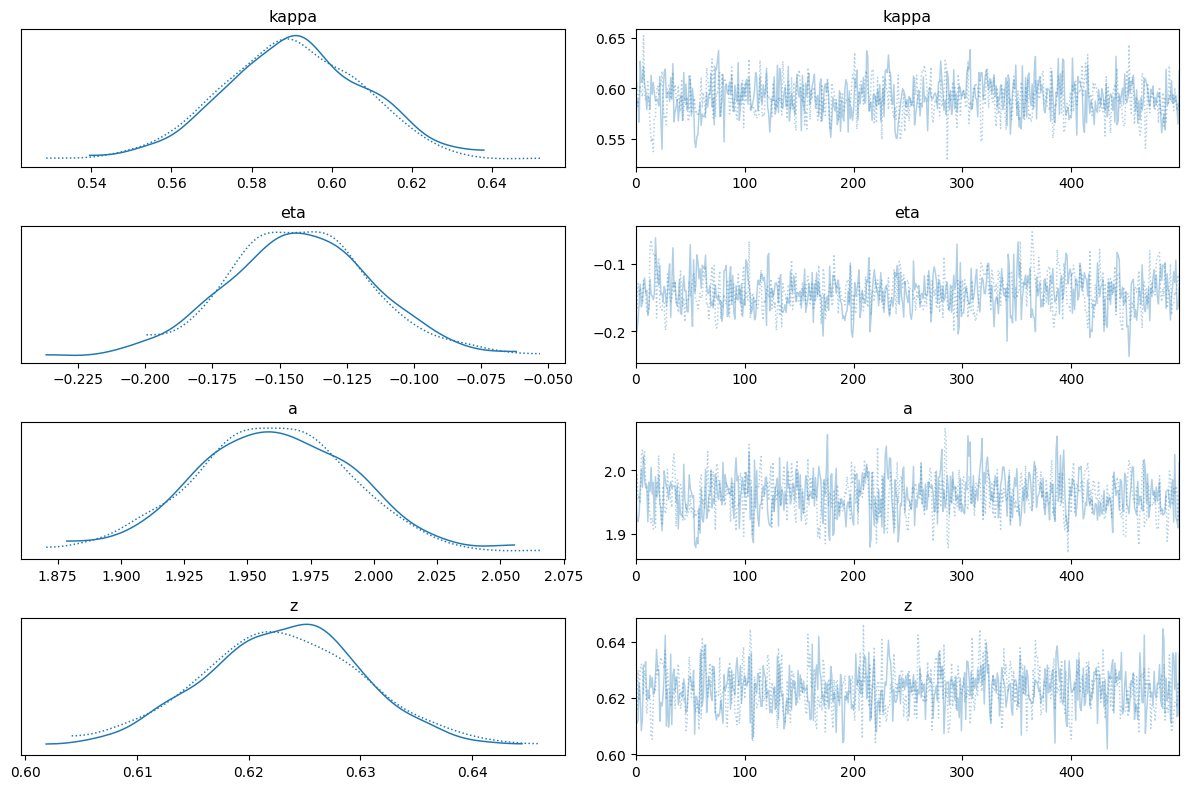

In [18]:
import arviz as az 
import matplotlib.pyplot as plt

az.plot_trace(tada_pymc_trace, var_names=["kappa", "eta", "a", "z"])
plt.tight_layout()

In [19]:
tada_summary = az.summary(tada_pymc_trace, var_names=["kappa", "eta", "a", "z"])
tada_summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
kappa,0.591,0.018,0.556,0.622,0.001,0.000,623.0,633.0,1.0
eta,-0.142,0.026,-0.194,-0.094,0.001,0.001,565.0,405.0,1.0
a,1.960,0.031,1.901,2.017,0.001,0.001,666.0,560.0,1.0
z,0.623,0.007,0.608,0.636,0.000,0.000,774.0,687.0,1.0


In [26]:
z_mean = tada_summary.loc['z', 'mean']
print(z_mean)
a_mean = tada_summary.loc['a', 'mean']
print(a_mean)
true_z = z_mean * (2 * a_mean) - a_mean
print(true_z)

0.623
1.96
0.4821599999999999


In [ ]:
def build_pymc_model(loglike_op, name_suffix=""):
    """
    Build a PyMC model with the given likelihood Op.
    
    Priors are chosen to be weakly informative but proper.
    """
    with pm.Model() as model:
        # eta: attention discount factor in [0, 1]
        # eta = pm.Beta(f"eta{name_suffix}", alpha=2.0, beta=2.0)
        eta = pm.Normal("eta", mu=0.0, sigma=1.0, initval=TRUE_PARAMS['eta'])
        
        # kappa: drift scaling (positive)
        kappa = pm.Gamma(f"kappa{name_suffix}", alpha=2.0, beta=4.0, initval=TRUE_PARAMS['kappa'])
        
        # a: initial boundary (positive)
        a = pm.Gamma(f"a{name_suffix}", alpha=4.0, beta=2.0, initval=TRUE_PARAMS['a'])
        # a = pm.HalfNormal(f"a{name_suffix}", sigma=2.0, initval=TRUE_PARAMS['a'])
        
        # b: boundary collapse rate (constrained so boundary doesn't collapse before max RT)
        # b must satisfy: a - b*M > 0, i.e., b < a/M
        # b_raw = pm.Beta(f"b_raw{name_suffix}", alpha=2.0, beta=2.0)
        # b = pm.Deterministic(f"b{name_suffix}", b_raw * a / M * 0.95)  # 0.95 for safety margin
        b = 0
        # x0: starting position (between -a and a)
        x0_raw = pm.Beta(f"x0_raw{name_suffix}", alpha=2.0, beta=2.0)
        x0 = pm.Deterministic(f"x0{name_suffix}", -a + 2.0 * a * x0_raw)
        
        # Stack parameters for the likelihood Op
        theta = pt.stack([eta, kappa, a, b, x0])
        
        # Add likelihood as a Potential
        pm.Potential(f"loglik{name_suffix}", loglike_op(theta))
    
    return model
model_jax = build_pymc_model(jax_loglike_op, "_jax")
print("=" * 60)
print("JAX + NUTS Sampling (numpyro backend)")
print("=" * 60)
print(f"Configuration: {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")


with model_jax:
    
    # Use numpyro backend - our custom Op is registered via jax_funcify
    trace_jax = pm.sample(
        draws=N_DRAWS,
        tune=N_TUNE,
        chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
        mp_ctx = 'spawn'
        
    )
    

JAX + NUTS Sampling (numpyro backend)
Configuration: 500 draws, 200 tune, 2 chains


  0%|          | 0/700 [00:00<?, ?it/s]

  0%|          | 0/700 [00:00<?, ?it/s]

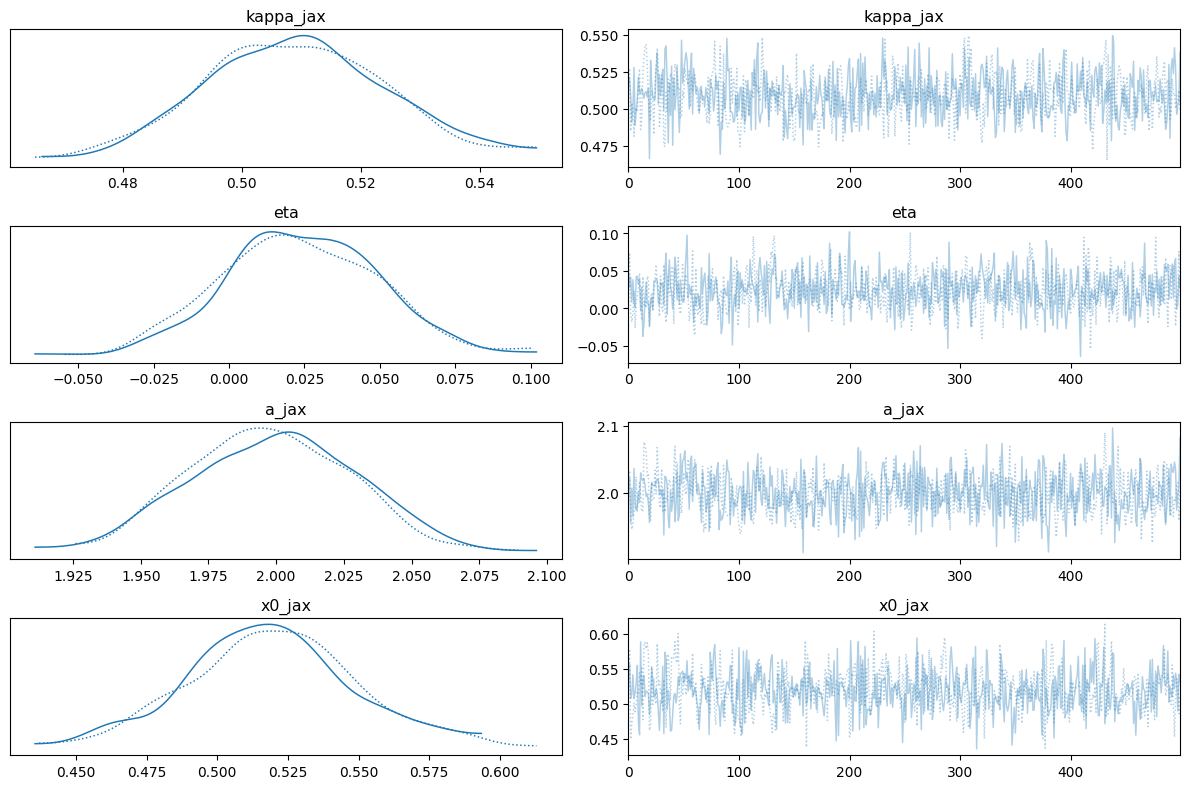

In [20]:
import arviz as az 
import matplotlib.pyplot as plt

az.plot_trace(trace_jax, var_names=["kappa_jax", "eta", "a_jax", "x0_jax"])
plt.tight_layout()